# Processing Inhibitor Data

____

In [7]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import inhibitors as INH

## Data Configuration
___

In [ ]:
# Loading data
        #RMS External Drive Location:    'E:/Co-translational folding (CoF) paper/Fig 3_Har/non pb'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 3_Har\Fig 3_Har analysis'


# ── Data Path ─────────────────────────────────────────────
#data_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Zhao lab shared folder' / 'Our papers' / 'co-translational folding paper' / 'Fig 2' / 'Fig 2_4xGFP har analysis'#Onedrive
data_dir = Path(r'E:/Co-translational folding (CoF) paper/Fig 4_Har_Fast/non pb') #RMS External Drive

#data_dir = 'General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 2\Fig 2_4xGFP har analysis'
 
# elongation rates
def elongation_rates (gene_length,dwell_time ):
    ke = gene_length/ dwell_time
    return np.round(ke,3)

# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
use_sem = True
show_summary = True
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None #0.5
threshold_percentage_for_runoff = 0.1
use_sigmoidal_fit = True
# ── Plotting Parameters ───────────────────────────────────
figsize = (5, 4)
ylims = (-0.1, 1.3)
xlims = (-5, 56.5)                              # limits needs to be set to include more than the fit_end_idx frames for the x-axis
fit_start_idx=inhibitor_frame_index             # int – fit range start (default: inh frame)
#fit_end_idx=last frame                         # int – fit range end (default: last frame)
results_folder = Path('temp')                  # Set to a Path to save plots or use Path('temp')
results_folder.mkdir(parents=True, exist_ok=True)


In [9]:
# parameters for linears fits 
r2_threshold = 0.95    # must match what you passed to plot_inhibitor
drug_diffusion_time_min = 1
frame_interval_sec = 60
# gene length
#g_length = 1826  # gene length total: pRS027 = 1826, pRS038 = 1852, pRS048 = 1855
#half_tag = 167   # gene length total
#g_length_effective = g_length-half_tag # gene_length_without_half_tag

## HA Channel (pRS027; 4xGFPfast)
___

── Lin.Extrap. Fit (4, 11) ──
  a (slope): -0.1201
  b (intercept): 0.9761
  Iss (baseline): 0.0000
  a_err: 0.0032
  b_err: 0.0149
  t½:      4.06 min
  τ_runoff (basal crossing): 8.13 min
  ke:      3.8784 aa/s
  χ²_red:  4.1028  (dof=6)
  R²:      0.971  (n=8)


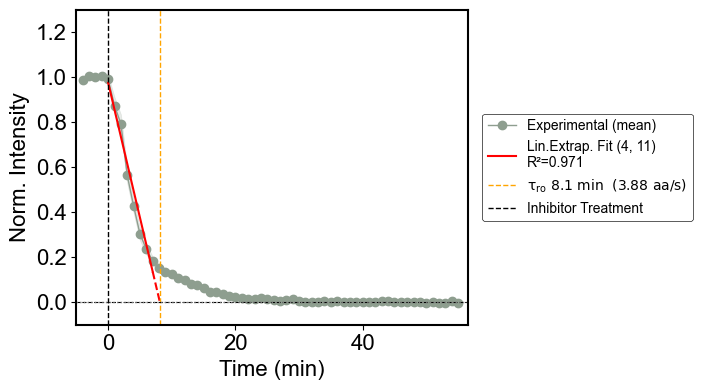

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26


In [11]:
substring_in_data_dir = 'pRS027'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027-only_HA_fit'
 
responding_indices_pRS027_HA, frames_pRS027_HA, intensities_pRS027_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,frame_interval_sec = frame_interval_sec,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS027_HA,                                 # np.ndarray – time array
    intensities_pRS027_HA,                            # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                            # int – treatment frame index
    results_folder=results_folder,                    # Path – save location
    plot_name=plot_name,                              # str – filename suffix
    responding_indices=responding_indices_pRS027_HA,  # list – which cells to include
    figsize=figsize,                                  # tuple
    use_sem=True,                                     # bool – SEM vs SD for error band
    show_individual_trajectories=False,               # bool – gray individual traces
    ylims=ylims,                                      # tuple – y-axis limits
    xlims=xlims,                                      # tuple – x-axis limits
    y_label='Norm. Intensity',                        # str
    treatment_label='Inhibitor',                      # str – label for treatment line
    show_treatment_line=True,                         # bool – vertical line at t=0
    show_fit=True,                                    # bool – overlay fitted curve
    show_runoff_time=True,                            # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                              # float – threshold for run-off (0.95 = 95%)
    remove_background_intensity=True,                 # subtract background & rescale to 0-1
    background_frames=10,                             # use last 10 frames within xlims window
    show_background_line=True,                        # dashed line at background level
    show_zero_y_axis=True,                            # dashed line at y = 0
    colors='#8E9E8F',
    # parameters for linear fits
    fit_model='linear_extrapolated',                  # 'linear'| 'linear_extrapolated'| 'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                      # int – fit range start (default: inh frame)
    gene_length_effective=1826-167,
    drug_diffusion_time_min = drug_diffusion_time_min,
    fit_end_idx=11,                                  # int – fit range end (fast = 11; slow = 17)
    #fit_end_range = (8,15),                           # range to fit data.
    r2_threshold = r2_threshold,                      # threshold for best fit selection
    
    
)
 
print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
 
 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])


## HA Channel (pRS048; Xbp1u-4xGFPfast)
___

── Lin.Extrap. Fit (4, 13) ──
  a (slope): -0.0623
  b (intercept): 0.9340
  Iss (baseline): 0.0000
  a_err: 0.0024
  b_err: 0.0142
  t½:      7.49 min
  τ_runoff (basal crossing): 14.98 min
  ke:      2.0118 aa/s
  χ²_red:  1.9178  (dof=8)
  R²:      0.979  (n=10)


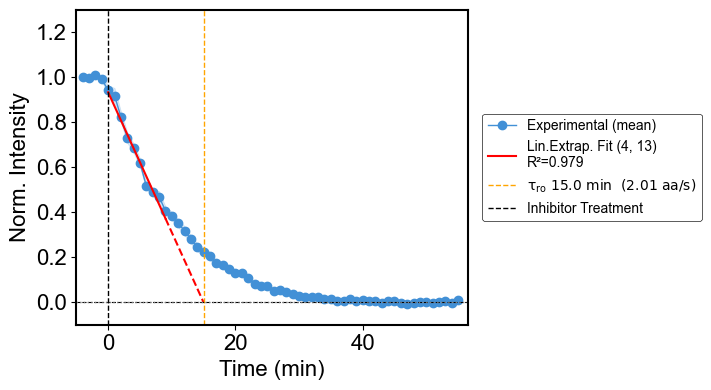

responding_indices_pRS048_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
number of responding trajectories for pRS048_HA: 22


In [12]:
substring_in_data_dir = 'pRS048'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS048-only_HA_fit'
 
responding_indices_pRS048_HA, frames_pRS048_HA, intensities_pRS048_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,frame_interval_sec = frame_interval_sec,
)

 
 
results=INH.plot_inhibitor(
    frames_pRS048_HA,                                 # np.ndarray – time array
    intensities_pRS048_HA,                            # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                            # int – treatment frame index
    results_folder=results_folder,                    # Path – save location
    plot_name=plot_name,                              # str – filename suffix
    responding_indices=responding_indices_pRS048_HA,  # list – which cells to include
    figsize=figsize,                                  # tuple
    use_sem=True,                                     # bool – SEM vs SD for error band
    show_individual_trajectories=False,               # bool – gray individual traces
    ylims=ylims,                                      # tuple – y-axis limits
    xlims=xlims,                                      # tuple – x-axis limits
    y_label='Norm. Intensity',                        # str
    treatment_label='Inhibitor',                      # str – label for treatment line
    show_treatment_line=True,                         # bool – vertical line at t=0
    show_fit=True,                                    # bool – overlay fitted curve
    show_runoff_time=True,                            # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                              # float – threshold for run-off (0.95 = 95%)
    remove_background_intensity=True,                 # subtract background & rescale to 0-1
    background_frames=10,                             # use last 10 frames within xlims window
    show_background_line=True,                        # dashed line at background level
    show_zero_y_axis=True,                            # dashed line at y = 0
    colors='#4290D6',
    # parameters for linear fits
    fit_model='linear_extrapolated',                  # 'linear'| 'linear_extrapolated'| 'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                      # int – fit range start (default: inh frame)
    fit_end_idx=13,                                   # int – fit range end (N = 13; C = 30)
    #fit_end_range = (11,20),                         # range to fit data.
    r2_threshold = r2_threshold,                      # threshold for best fit selection
    gene_length_effective=1855-167,                   # 1855-167 = 1688
    drug_diffusion_time_min = drug_diffusion_time_min,
)
 
print("responding_indices_pRS048_HA:", responding_indices_pRS048_HA)
print("number of responding trajectories for pRS048_HA:", len(responding_indices_pRS048_HA))

 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])

## HA Channel (pRS038; 4xGFPfast-Xbp1u)
___

── Lin.Extrap. Fit (4, 30) ──
  a (slope): -0.0267
  b (intercept): 0.9341
  Iss (baseline): 0.0000
  a_err: 0.0005
  b_err: 0.0073
  t½:      17.50 min
  τ_runoff (basal crossing): 35.01 min
  ke:      0.8259 aa/s
  χ²_red:  1.2561  (dof=25)
  R²:      0.990  (n=27)


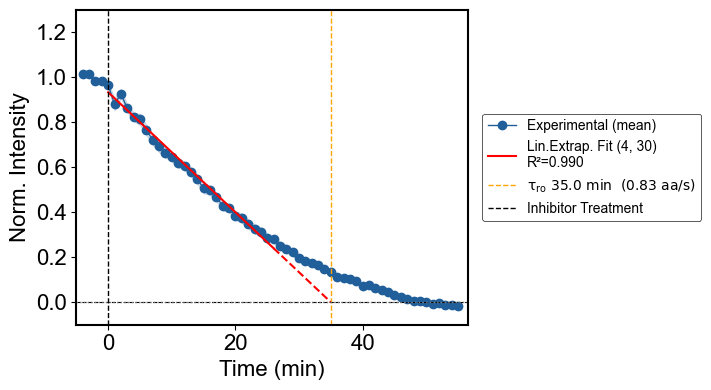

responding_indices_pRS038_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
number of responding trajectories for pRS038_HA: 24


In [13]:
substring_in_data_dir = 'pRS038'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS038_HA_fit'
 
responding_indices_pRS038_HA, frames_pRS038_HA, intensities_pRS038_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,frame_interval_sec = frame_interval_sec,
)

 
 
results=INH.plot_inhibitor(
    frames_pRS038_HA,                                 # np.ndarray – time array
    intensities_pRS038_HA,                            # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                            # int – treatment frame index
    results_folder=results_folder,                    # Path – save location
    plot_name=plot_name,                              # str – filename suffix
    responding_indices=responding_indices_pRS038_HA,  # list – which cells to include
    figsize=figsize,                                  # tuple
    use_sem=True,                                     # bool – SEM vs SD for error band
    show_individual_trajectories=False,               # bool – gray individual traces
    ylims=ylims,                                      # tuple – y-axis limits
    xlims=xlims,                                      # tuple – x-axis limits
    y_label='Norm. Intensity',                        # str
    treatment_label='Inhibitor',                      # str – label for treatment line
    show_treatment_line=True,                         # bool – vertical line at t=0
    show_fit=True,                                    # bool – overlay fitted curve
    show_runoff_time=True,                            # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                              # float – threshold for run-off (0.95 = 95%)
    remove_background_intensity=True,                 # subtract background & rescale to 0-1
    background_frames=10,                             # use last 10 frames within xlims window
    show_background_line=True,                        # dashed line at background level
    show_zero_y_axis=True,                            # dashed line at y = 0
    colors='#215F9A',
    # parameters for linear fits
    fit_model='linear_extrapolated',                  # 'linear'| 'linear_extrapolated'| 'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                      # int – fit range start (default: inh frame)
    fit_end_idx=30,                                   # int – fit range end (N = 13; C = 30)
    #fit_end_range = (29,38),                          # range to fit data.
    r2_threshold = r2_threshold,                      # threshold for best fit selection
    gene_length_effective=1852-167,
    drug_diffusion_time_min = drug_diffusion_time_min,
)
 
print("responding_indices_pRS038_HA:", responding_indices_pRS038_HA)
print("number of responding trajectories for pRS038_HA:", len(responding_indices_pRS038_HA))

 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])

## Normalized Comparison Graphs
___

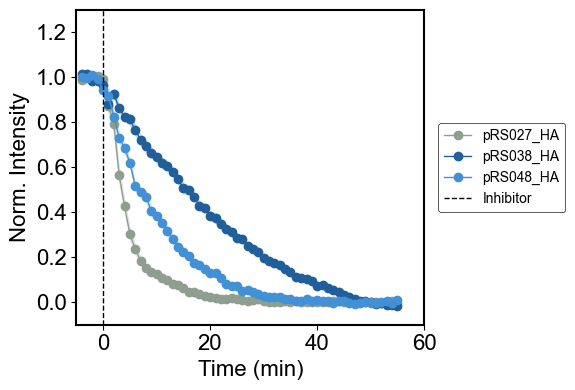

[None, None, None]

In [16]:
INH.plot_multiple_inhibitors(
    [frames_pRS027_HA, frames_pRS038_HA, frames_pRS048_HA,],
    [intensities_pRS027_HA, intensities_pRS038_HA, intensities_pRS048_HA],
    inhibitor_frame_index,
    responding_indices_list=[responding_indices_pRS027_HA, responding_indices_pRS038_HA, responding_indices_pRS048_HA],
    colors=['#8E9E8F', '#215F9A', '#4290D6'],
    legend_labels=['pRS027_HA', 'pRS038_HA', 'pRS048_HA'],
    plot_name='Xbp1us_fast_norm_6x4',
    #threshold_percentage_for_runoff=-0.4,
    ylims=ylims,
    xlims=(-5, 60),
    figsize=(6, 4),
    use_sem=True,
    show_individual_trajectories=show_individual_trajectories,
    show_treatment_line=True,                        # bool – vertical line at t=0
    show_runoff_time=False,                           # bool – draw t½ and τ_runoff lines
    remove_background_intensity=True,                 # subtract background & rescale to 0-1
    background_frames=10,                             # use last 10 frames within xlims window
    show_background_line=False,                        # dashed line at background level
    show_zero_y_axis=False,                            # dashed line at y = 0
    results_folder=results_folder,
)